In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

In [3]:
locations = ['A', 'B']
similarities = np.linspace(0, 1, 5)
neg_similarities = np.linspace(-1, 0, 5)

prod_loc = list(product(locations, locations))
print(prod_loc)

[('A', 'A'), ('A', 'B'), ('B', 'A'), ('B', 'B')]


In [4]:
# Define the uniform distribution
def uniform(pair):
    return 1 / len(locations)

# Define kronecker delta
def kronecker_delta(pair):
    loc1, loc2 = pair
    return 1 if loc1 == loc2 else 0 

# Define kronecker delta
def complement_delta(pair):
    loc1, loc2 = pair
    return 0 if loc1 == loc2 else 1 

In [5]:
mixed_distributions = []
for sim in similarities:
    mixed_prob = [sim * kronecker_delta(pair) + (1 - sim) * uniform(pair) for pair in prod_loc]
    mixed_distributions.append(mixed_prob)

In [6]:
inverse_distributions = []
for sim in neg_similarities:
    mixed_prob = [sim * complement_delta(pair) + (1 - sim) * uniform(pair) for pair in prod_loc]
    inverse_distributions.append(mixed_prob)

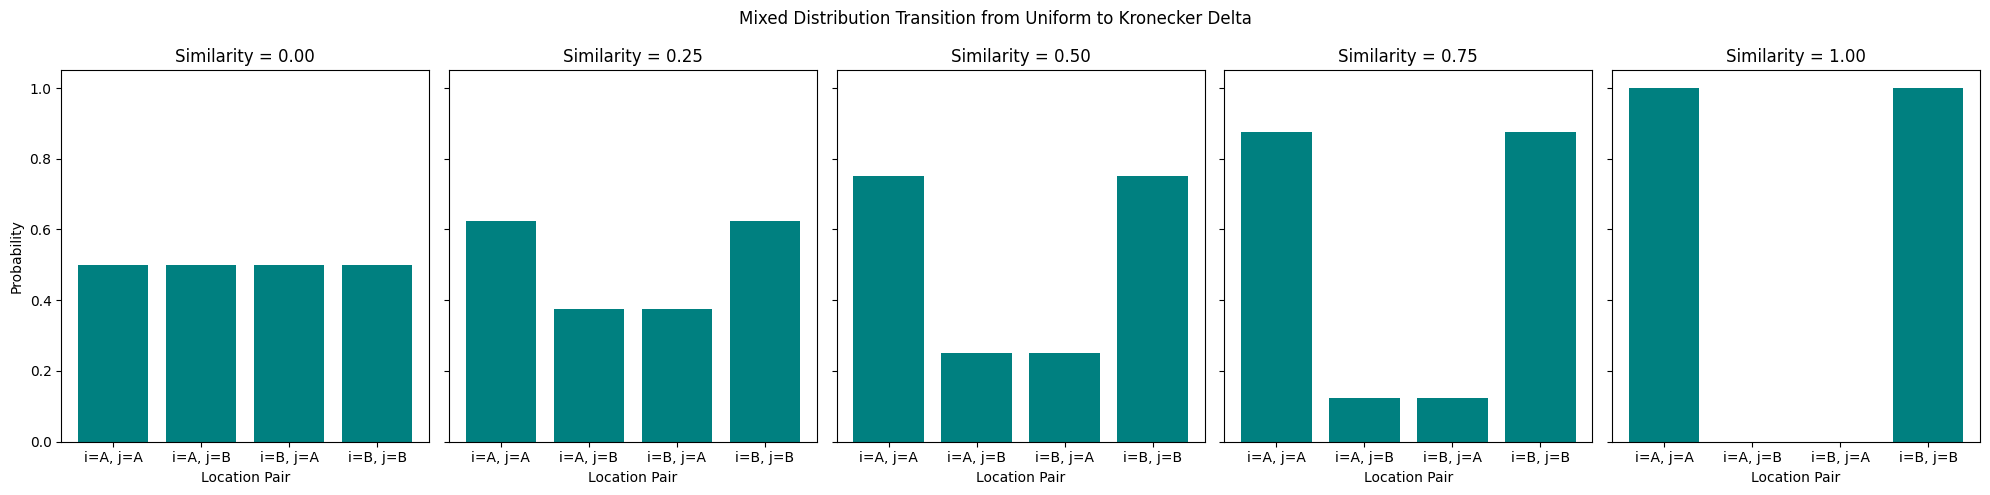

In [7]:
# Create plots for each similarity value
fig, axes = plt.subplots(1, len(similarities), figsize=(20, 5), sharey=True)
for i, ax in enumerate(axes):
    ax.bar(range(len(prod_loc)), mixed_distributions[i], color='teal')
    ax.set_title(f'Similarity = {similarities[i]:.2f}')
    ax.set_xlabel('Location Pair')
    ax.set_xticks(range(len(prod_loc)))
    ax.set_xticklabels([f'i={p[0]}, j={p[1]}' for p in prod_loc])
    if i == 0:
        ax.set_ylabel('Probability')

plt.suptitle('Mixed Distribution Transition from Uniform to Kronecker Delta')
plt.tight_layout()
plt.show()

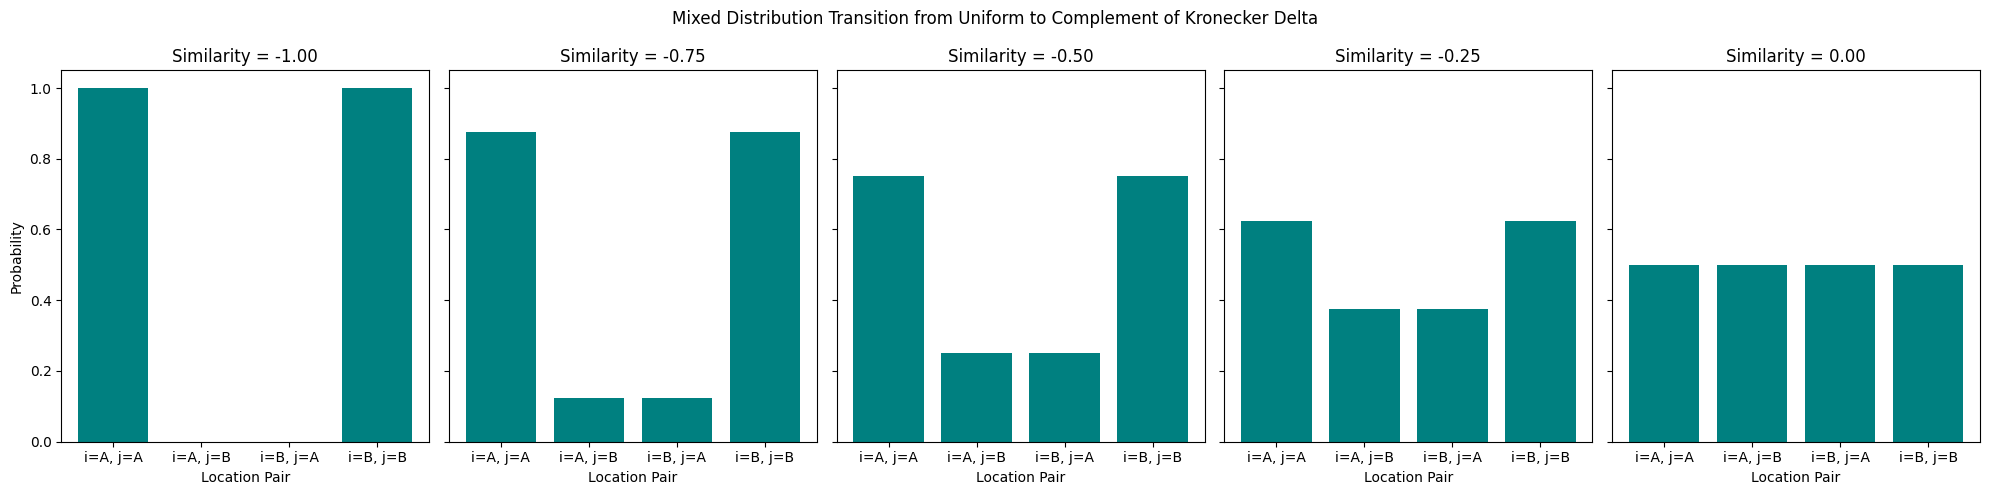

In [8]:
# Create plots for each similarity value
fig, axes = plt.subplots(1, len(neg_similarities), figsize=(20, 5), sharey=True)
for i, ax in enumerate(axes):
    ax.bar(range(len(prod_loc)), inverse_distributions[i], color='teal')
    ax.set_title(f'Similarity = {neg_similarities[i]:.2f}')
    ax.set_xlabel('Location Pair')
    ax.set_xticks(range(len(prod_loc)))
    ax.set_xticklabels([f'i={p[0]}, j={p[1]}' for p in prod_loc])
    if i == 0:
        ax.set_ylabel('Probability')

plt.suptitle('Mixed Distribution Transition from Uniform to Complement of Kronecker Delta')
plt.tight_layout()
plt.show()